# Maintenance prédictive — comparaison Régression logistique / Histogram Gradient Boosting

## Objectif concret

Ce notebook reprend le TP de classification binaire `label_failure_next_24h` et entraîne **deux modèles sur exactement les mêmes observations et les mêmes 88 variables explicatives** : la régression logistique de référence et `HistGradientBoostingClassifier`. L'objectif est de déterminer si le modèle alternatif dépasse la limite linéaire de la baseline à un coût acceptable en temps, complexité et interprétabilité.

La régression **linéaire** prédit une valeur continue et ne convient pas directement à une cible oui/non. Le TP original emploie en réalité une **régression logistique**, c'est-à-dire un classifieur dont la frontière de décision reste linéaire. `Histogram Gradient Boosting` peut représenter des relations non linéaires et des interactions entre capteurs.

## Prérequis et point de départ observable

- ouvrir ce notebook depuis la racine du projet `indusense` ;
- disposer de `datas/gold_dataset_20260622-080603.csv` ;
- exécuter les cellules dans l'ordre ;
- vérifier les marqueurs de validation avant de poursuivre.

Le protocole conserve le découpage chronologique `train → validation → test`. La consigne du formateur demande le même train/test : la validation existante est conservée en plus pour régler les seuils sans utiliser le test. Le test ayant déjà été lu dans le TP initial, la comparaison reste valable pédagogiquement, mais une validation finale de production nécessiterait une période future encore vierge.


In [1]:
from pathlib import Path

import pandas as pd
from tabulate import tabulate

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / 'datas' / 'gold_dataset_20260622-080603.csv'

assert (PROJECT_ROOT / 'pyproject.toml').exists(), (
    'Ouvrir le notebook depuis la racine du projet indusense.'
)
assert DATA_PATH.exists(), f'Fichier Gold introuvable : {DATA_PATH}'

# Les dates sont converties dès la lecture afin de permettre les contrôles chronologiques.
gold = pd.read_csv(
    DATA_PATH,
    parse_dates=['window_start', 'window_end'],
)
PREDICTION_TIME_COLUMN = 'window_end'
gold = gold.sort_values(
    ['machine_id_std', PREDICTION_TIME_COLUMN],
    kind='stable',
).reset_index(drop=True)

# Une ligne doit représenter un seul instant de prédiction pour une seule machine.
grain_columns = ['machine_id_std', PREDICTION_TIME_COLUMN]
duplicate_grain_count = int(gold.duplicated(grain_columns).sum())
assert duplicate_grain_count == 0, (
    f'{duplicate_grain_count} doublons détectés sur le grain {grain_columns}.'
)

window_durations = gold['window_end'] - gold['window_start']
assert window_durations.eq(pd.Timedelta(hours=1)).all(), (
    'Chaque fenêtre Gold doit couvrir exactement une heure.'
)

dataset_summary = [
    ['Fichier chargé', DATA_PATH.name],
    ['Nombre de lignes', f'{len(gold):,}'.replace(',', ' ')],
    ['Nombre de colonnes', gold.shape[1]],
    ['Nombre de machines', gold['machine_id_std'].nunique()],
    ['Première ancre', gold[PREDICTION_TIME_COLUMN].min()],
    ['Dernière ancre', gold[PREDICTION_TIME_COLUMN].max()],
    ['Durée de chaque fenêtre', '1 heure'],
    ['Doublons machine + ancre', duplicate_grain_count],
]

print(tabulate(dataset_summary, headers=['Contrôle', 'Résultat'], tablefmt='github'))

| Contrôle                 | Résultat                         |
|--------------------------|----------------------------------|
| Fichier chargé           | gold_dataset_20260622-080603.csv |
| Nombre de lignes         | 134 280                          |
| Nombre de colonnes       | 100                              |
| Nombre de machines       | 15                               |
| Première ancre           | 2025-06-01 01:00:00              |
| Dernière ancre           | 2026-06-09 00:00:00              |
| Durée de chaque fenêtre  | 1 heure                          |
| Doublons machine + ancre | 0                                |


## Lecture du résultat précédent : quel dataset avons-nous ?

Le Gold dataset contient **134 280 observations**, **100 colonnes** et **15 machines** entre le 1er juin 2025 et le 9 juin 2026. Une observation correspond à une machine et à une ancre horaire ; ce n'est donc pas une panne individuelle, mais un état calculé à partir d'une fenêtre d'une heure. Les `0` doublons confirment que chaque couple `(machine, ancre)` apparaît une seule fois : le **grain** annoncé est respecté. Le grain est l'unité exacte représentée par une ligne.

Ce contrôle ne dit encore rien sur la capacité à prédire. Il établit seulement que les données ont la structure attendue. Les fenêtres successives d'une même machine restent proches dans le temps et peuvent partager de l'information : les 134 280 lignes ne doivent donc pas être interprétées comme autant d'événements totalement indépendants.

## Choisir la cible et vérifier le découpage temporel

L'**horizon de prédiction** est la durée future couverte par la question métier. Nous retenons `label_failure_next_24h` : `1` signifie qu'une panne est observée dans les 24 heures suivantes, `0` signifie qu'aucune panne n'y est observée.

Le fichier fournit trois jeux dans `split_set`. Le jeu d'**entraînement** ajuste le futur modèle ; la **validation** sert à comparer des choix et à fixer le seuil ; le **test** reste à l'écart jusqu'à l'évaluation finale. La cellule suivante vérifie que ces périodes ne se chevauchent pas et mesure le taux de positifs dans chacune.

### Pourquoi cet ordre est indispensable

Le découpage est **chronologique** : le train est le passé connu, la validation une période plus récente sur laquelle on prend les décisions de modélisation, puis le test représente une période future non consultée. Un découpage aléatoire mélangerait potentiellement des observations voisines dans le passé et le futur ; il donnerait une estimation trop optimiste de la généralisation. La validation n'est donc pas un second entraînement, et le test n'est pas un espace d'essais supplémentaire.

**À vérifier après la cellule 3.** Le tableau doit présenter les trois jeux dans l'ordre `train`, `validation`, `test`, avec une dernière ancre du train strictement antérieure à la première ancre de validation, puis le même ordre entre validation et test. Le taux de panne est la **prévalence** de la classe positive ; il servira de repère pour interpréter la PR-AUC.

In [2]:
TARGET_COLUMN = 'label_failure_next_24h'
SPLIT_COLUMN = 'split_set'
EXPECTED_SPLITS = ['train', 'validation', 'test']

required_columns = {
    'machine_id_std', 'window_start', PREDICTION_TIME_COLUMN, TARGET_COLUMN, SPLIT_COLUMN
}
missing_required_columns = sorted(required_columns.difference(gold.columns))
assert not missing_required_columns, (
    f'Colonnes obligatoires absentes : {missing_required_columns}'
)

observed_splits = gold[SPLIT_COLUMN].dropna().unique().tolist()
assert observed_splits == EXPECTED_SPLITS, (
    f'Ordre des splits inattendu : {observed_splits}'
)
assert set(gold[TARGET_COLUMN].dropna().unique()).issubset({False, True, 0, 1}), (
    f'La cible {TARGET_COLUMN} doit être binaire.'
)
assert not gold[TARGET_COLUMN].isna().any(), 'La cible contient des valeurs manquantes.'

split_rows = []
for split_name in EXPECTED_SPLITS:
    split_data = gold.loc[gold[SPLIT_COLUMN].eq(split_name)]
    split_rows.append([
        split_name,
        len(split_data),
        split_data[PREDICTION_TIME_COLUMN].min(),
        split_data[PREDICTION_TIME_COLUMN].max(),
        int(split_data[TARGET_COLUMN].sum()),
        f"{split_data[TARGET_COLUMN].mean():.2%}",
    ])

split_periods = {row[0]: (row[2], row[3]) for row in split_rows}
assert split_periods['train'][1] < split_periods['validation'][0]
assert split_periods['validation'][1] < split_periods['test'][0]

print(tabulate(
    split_rows,
    headers=['Jeu', 'Lignes', 'Première ancre', 'Dernière ancre', 'Positifs', 'Taux positif'],
    tablefmt='github',
))

| Jeu        |   Lignes | Première ancre      | Dernière ancre      |   Positifs | Taux positif   |
|------------|----------|---------------------|---------------------|------------|----------------|
| train      |    93990 | 2025-06-01 01:00:00 | 2026-02-17 02:00:00 |      15598 | 16.60%         |
| validation |    20145 | 2026-02-17 03:00:00 | 2026-04-14 01:00:00 |       3472 | 17.24%         |
| test       |    20145 | 2026-04-14 02:00:00 | 2026-06-09 00:00:00 |       3478 | 17.26%         |


## Lecture du résultat précédent : les périodes sont-elles bien séparées ?

Le train contient **93 990 lignes**, puis la validation et le test **20 145 lignes chacun**. Les bornes s'enchaînent sans chevauchement : le train s'arrête le 17 février 2026 à 02 h, la validation commence à 03 h ; elle s'arrête le 14 avril à 01 h et le test commence à 02 h. Cela confirme un protocole passé → futur cohérent avec l'usage réel.

La prévalence passe de **16,60 %** sur le train à **17,24 %** sur la validation et **17,26 %** sur le test. Ces taux proches indiquent que la fréquence globale des pannes reste relativement stable entre les trois périodes. Cela ne prouve toutefois pas que les relations entre capteurs et pannes sont identiques : un changement de comportement des variables peut exister même avec une prévalence stable.

**Conclusion de l'étape :** les rôles sont séparés correctement. Le train servira au `fit`, la validation aux choix, et le test à la mesure finale. Voir [la section sur les trois jeux](../../../../docs/02-sprint-2/04-revisions/06-evaluation-des-modeles.md#2-séparer-entraînement-validation-et-test).

## Séparer les features et la cible sans fuite

Les colonnes `future_incident_count_*` décrivent directement le futur : elles doivent être exclues. Les autres `label_failure_next_*` sont également des cibles futures et ne peuvent pas devenir des features.

L'identifiant de machine, les deux timestamps bruts et `split_set` sont conservés pour la traçabilité et les contrôles, mais pas fournis à cette première baseline. Une **baseline** est un premier modèle simple qui sert de référence.

La cellule suivante construit la liste des features autorisées, crée les matrices `X` et les cibles `y` pour chaque période, puis vérifie leurs dimensions. Elle ne réalise encore ni imputation, ni standardisation, ni entraînement.

### Règle de disponibilité à l'instant de prédiction

Pour décider à `window_end`, chaque variable explicative doit être connue au plus tard à `window_end`. Une colonne `future_incident_count_*` ou un autre `label_failure_next_*` décrit une conséquence future : l'utiliser rendrait la prédiction artificiellement facile et créerait une **fuite de données**. Les identifiants, les dates brutes et `split_set` sont retirés de cette baseline afin que le modèle n'apprenne pas un raccourci lié à la machine ou à la période plutôt qu'un signal de maintenance.

`X_train`, `X_validation` et `X_test` sont les **matrices de variables explicatives** ; `y_train`, `y_validation` et `y_test` sont les **vecteurs de cible** correspondants. **À vérifier après la cellule 5 :** les trois assertions confirment l'absence de labels futurs et de comptes futurs dans les features, et les tableaux doivent montrer le même nombre de colonnes pour les trois jeux.

In [3]:
label_columns = [column for column in gold.columns if column.startswith('label_failure_next_')]
future_information_columns = [
    column for column in gold.columns if column.startswith('future_incident_count_')
]
identifier_columns = ['machine_id_std']
raw_time_columns = ['window_start', 'window_end']
control_columns = [SPLIT_COLUMN]

excluded_columns = list(dict.fromkeys(
    identifier_columns
    + raw_time_columns
    + control_columns
    + label_columns
    + future_information_columns
))
feature_columns = [column for column in gold.columns if column not in excluded_columns]

# Cette baseline accepte uniquement des variables numériques ou booléennes.
non_numeric_features = gold[feature_columns].select_dtypes(
    exclude=['number', 'bool'],
).columns.tolist()
assert TARGET_COLUMN not in feature_columns
assert not set(future_information_columns).intersection(feature_columns)
assert not set(label_columns).intersection(feature_columns)
assert not non_numeric_features, f'Features non numériques : {non_numeric_features}'

def extract_split(split_name):
    mask = gold[SPLIT_COLUMN].eq(split_name)
    X = gold.loc[mask, feature_columns].copy()
    y = gold.loc[mask, TARGET_COLUMN].astype('int8').copy()
    assert len(X) == len(y)
    assert X.index.equals(y.index)
    return X, y

X_train, y_train = extract_split('train')
X_validation, y_validation = extract_split('validation')
X_test, y_test = extract_split('test')

exclusion_summary = [
    ['Identifiants', len(identifier_columns), ', '.join(identifier_columns)],
    ['Temps bruts', len(raw_time_columns), ', '.join(raw_time_columns)],
    ['Contrôle du split', len(control_columns), ', '.join(control_columns)],
    ['Labels futurs', len(label_columns), ', '.join(label_columns)],
    ['Comptages futurs', len(future_information_columns), ', '.join(future_information_columns)],
]
split_shape_summary = [
    ['train', X_train.shape[0], X_train.shape[1], int(y_train.sum()), int(X_train.isna().sum().sum())],
    ['validation', X_validation.shape[0], X_validation.shape[1], int(y_validation.sum()), int(X_validation.isna().sum().sum())],
    ['test', X_test.shape[0], X_test.shape[1], int(y_test.sum()), int(X_test.isna().sum().sum())],
]

print('Politique d’exclusion :')
print(tabulate(
    exclusion_summary,
    headers=['Famille', 'Nombre', 'Colonnes'],
    tablefmt='github',
))
print(f'\nFeatures retenues : {len(feature_columns)}')
print(f'Premières features : {feature_columns[:8]}')
print('\nJeux prêts pour la prochaine partie :')
print(tabulate(
    split_shape_summary,
    headers=['Jeu', 'Lignes X', 'Colonnes X', 'Positifs y', 'NaN dans X'],
    tablefmt='github',
))
print('\nPARTIE_1_VALIDEE : données séparées sans imputation, standardisation ni modèle.')

Politique d’exclusion :
| Famille           |   Nombre | Colonnes                                                                                                  |
|-------------------|----------|-----------------------------------------------------------------------------------------------------------|
| Identifiants      |        1 | machine_id_std                                                                                            |
| Temps bruts       |        2 | window_start, window_end                                                                                  |
| Contrôle du split |        1 | split_set                                                                                                 |
| Labels futurs     |        4 | label_failure_next_6h, label_failure_next_12h, label_failure_next_24h, label_failure_next_48h             |
| Comptages futurs  |        4 | future_incident_count_6h, future_incident_count_12h, future_incident_count_24h, future_incident_c

## Lecture du résultat précédent : que donnera-t-on réellement au modèle ?

Sur les **100 colonnes** initiales, 12 sont exclues du modèle : 1 identifiant, 2 timestamps, 1 colonne de contrôle, 4 labels futurs et 4 comptages futurs. Il reste **88 variables explicatives**. Cette exclusion est une décision de protocole, pas un nettoyage arbitraire : elle empêche le modèle d'utiliser la réponse attendue ou une information postérieure à `window_end`.

Les matrices contiennent encore des valeurs manquantes : **185 053** dans le train, **37 875** dans la validation et **37 739** dans le test. Rapporté au nombre total de cases, cela représente environ **2,24 %**, **2,14 %** et **2,13 %**. Aucune ligne n'est supprimée ici ; l'imputation sera apprise plus tard dans le Pipeline, uniquement sur le train.

Le marqueur `PARTIE_1_VALIDEE` signifie que la séparation `X/y` est techniquement cohérente. Il ne signifie pas encore qu'un modèle a été entraîné ni qu'il est performant. Voir [la démarche Indusense sans fuite](../../../../docs/02-sprint-2/04-revisions/05-classification-binaire-et-decoupage-temporel.md#démarche-pour-indusense).

## Mesurer et traiter le déséquilibre des classes

Une classe est **minoritaire** lorsqu'elle contient nettement moins d'exemples que l'autre. Ici, les pannes sont moins fréquentes que les non-pannes. Une prédiction toujours égale à `0` obtiendrait donc une accuracy élevée sans détecter la moindre panne. L'**accuracy** est la proportion totale de prédictions correctes ; elle ne sera pas notre métrique principale.

La régression logistique utilisera `class_weight='balanced'`. Scikit-learn donnera automatiquement plus de poids aux erreurs commises sur la classe minoritaire, avec des poids calculés uniquement à partir du jeu d'entraînement. `scale_pos_weight` répond au même besoin pour XGBoost, mais aucun modèle XGBoost n'est entraîné dans ce TP.

La cellule suivante calcule la répartition des classes dans chaque période, les poids théoriques du train et l'accuracy trompeuse d'une règle qui prédirait toujours l'absence de panne.

### Lire le déséquilibre avec les mots du cours

La classe `1` est la **classe positive** : une panne dans l'horizon de 24 heures. La classe `0` est la **classe négative** : pas de panne dans cet horizon. L'accuracy vaut `(TP + TN) / (TP + TN + FP + FN)` ; elle peut être élevée simplement parce que les non-pannes sont nombreuses. Une règle « toujours 0 » a en revanche un **rappel** de 0 : elle ne détecte aucune panne.

`class_weight='balanced'` ne fabrique pas de pannes et ne change pas les données. Pendant l'ajustement, il donne plus de poids à l'erreur sur une panne pour que le modèle ne privilégie pas mécaniquement la classe majoritaire. **À vérifier après la cellule 7 :** la barre des pannes doit être minoritaire dans les trois jeux et l'accuracy de la règle toujours `0` doit être lue comme une référence trompeuse, non comme une performance acceptable.

| Jeu        |   Non-pannes |   Pannes | Taux de panne   | Accuracy toujours 0   |
|------------|--------------|----------|-----------------|-----------------------|
| train      |        78392 |    15598 | 16.60%          | 83.40%                |
| validation |        16673 |     3472 | 17.24%          | 82.76%                |
| test       |        16667 |     3478 | 17.26%          | 82.74%                |

Poids théoriques du train : classe 0 = 0.599, classe 1 = 3.013
Une règle toujours égale à 0 atteindrait 83.40% d'accuracy sur le train, avec 0 % de rappel.


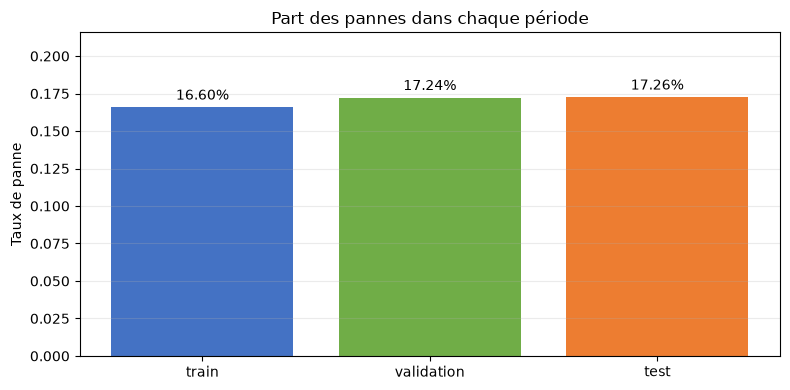

In [4]:
import matplotlib.pyplot as plt
import numpy as np

targets_by_split = {
    'train': y_train,
    'validation': y_validation,
    'test': y_test,
}
class_rows = []
for split_name, target in targets_by_split.items():
    negative_count = int(target.eq(0).sum())
    positive_count = int(target.eq(1).sum())
    class_rows.append([
        split_name,
        negative_count,
        positive_count,
        f'{positive_count / len(target):.2%}',
        f'{negative_count / len(target):.2%}',
    ])

train_negative_count = int(y_train.eq(0).sum())
train_positive_count = int(y_train.eq(1).sum())
balanced_weights = {
    0: len(y_train) / (2 * train_negative_count),
    1: len(y_train) / (2 * train_positive_count),
}
majority_accuracy = train_negative_count / len(y_train)

print(tabulate(
    class_rows,
    headers=['Jeu', 'Non-pannes', 'Pannes', 'Taux de panne', 'Accuracy toujours 0'],
    tablefmt='github',
))
print(f"\nPoids théoriques du train : classe 0 = {balanced_weights[0]:.3f}, classe 1 = {balanced_weights[1]:.3f}")
print(f"Une règle toujours égale à 0 atteindrait {majority_accuracy:.2%} d'accuracy sur le train, avec 0 % de rappel.")

positive_rates = [target.mean() for target in targets_by_split.values()]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(targets_by_split.keys(), positive_rates, color=['#4472C4', '#70AD47', '#ED7D31'])
ax.bar_label(bars, labels=[f'{rate:.2%}' for rate in positive_rates], padding=3)
ax.set_title('Part des pannes dans chaque période')
ax.set_ylabel('Taux de panne')
ax.set_ylim(0, max(positive_rates) * 1.25)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

## Lecture du résultat précédent : pourquoi l'accuracy nous tromperait-elle ?

Dans le train, on observe **15 598 pannes** contre **78 392 non-pannes**. Une règle qui répond toujours « pas de panne » aurait donc **83,40 % d'accuracy**, alors qu'elle manquerait les 15 598 pannes : son rappel serait de **0 %**. Ce résultat illustre pourquoi une valeur élevée n'est utile que si la métrique correspond au besoin métier.

Le poids théorique de la classe positive vaut **3,013**, contre **0,599** pour la classe négative. Une erreur sur une panne pèsera donc environ cinq fois plus qu'une erreur sur une non-panne pendant l'entraînement. Cela pousse le modèle à prêter attention aux pannes rares, mais ne garantit ni un bon rappel ni une bonne précision : ces qualités devront être mesurées.

**Conclusion de l'étape :** l'accuracy restera une information secondaire. Pour ce cas, nous suivrons surtout la courbe précision-rappel, puis le rappel, la précision, F2 et les nombres de faux positifs/faux négatifs. Voir [les métriques de classification](../../../../docs/02-sprint-2/04-revisions/06-evaluation-des-modeles.md#5-classification-prédire-une-classe).

## Construire et entraîner la baseline

Une **baseline** est un premier modèle simple servant de référence pour juger les modèles futurs. Nous utilisons une **régression logistique** : malgré son nom, c'est un algorithme de classification. Il combine linéairement les variables, puis applique une fonction logistique qui ramène le résultat entre 0 et 1. Dans ce notebook pondéré, cette sortie est traitée comme un score de risque à ordonner et à seuiller ; sa calibration en probabilité réelle n'est pas démontrée.

Un **Pipeline** scikit-learn enchaîne les transformations dans un ordre fixe :

1. `SimpleImputer(strategy='median')` remplace chaque valeur manquante par la médiane de sa colonne ;
2. `StandardScaler()` centre et réduit les variables afin qu'elles soient sur des échelles comparables ;
3. `LogisticRegression(class_weight='balanced')` apprend la relation entre les features et la cible en compensant le déséquilibre.

L'appel à `fit` ne reçoit que le train. Les médianes, moyennes, écarts-types et coefficients sont donc appris sans regarder la validation ni le test. La cellule suivante entraîne ce pipeline et produit des scores pour le train et la validation.

### Ce que le Pipeline apprend, dans quel ordre

L'**imputation** complète une valeur manquante avec la médiane calculée sur le train : elle rend les données exploitables sans consulter le futur. La **standardisation** retire la moyenne et divise par l'écart-type appris sur le train ; les variables sont ainsi comparables pour l'optimisation de la régression logistique. Enfin, la régression logistique apprend des **coefficients** qui combinent les variables explicatives pour ordonner les observations selon leur risque de panne.

Le Pipeline garantit que, lors de `predict_proba(X_validation)`, les mêmes transformations déjà apprises sur le train sont appliquées à la validation, sans nouveau `fit`. **À vérifier après la cellule 9 :** le tableau doit afficher les trois étapes, le nombre de lignes du train, le nombre de variables explicatives et un nombre d'itérations inférieur à `max_iter=2000`. Sinon, la convergence du modèle est à examiner avant de commenter les métriques.

## Étape 1 — Entraîner les deux modèles sur les mêmes données

La cellule suivante reconstruit la baseline `LogisticRegression` et entraîne `HistGradientBoostingClassifier`. Les deux modèles reçoivent `X_train` et `y_train` ; aucune ligne de validation ou de test ne participe au `fit`.

### Hyperparamètres du candidat et méthode de choix

Un **hyperparamètre** est un réglage fixé avant l'entraînement, contrairement aux paramètres appris par le modèle.

- `learning_rate=0.08` et `max_iter=200` : petits pas et davantage d'itérations pour un apprentissage progressif ; choix manuel.
- `max_leaf_nodes=31` et `min_samples_leaf=20` : capacité proche des valeurs usuelles de scikit-learn, sans créer de feuilles trop petites.
- `l2_regularization=1.0` : pénalise les prédictions extrêmes des feuilles pour limiter le surapprentissage ; choix manuel conservateur.
- `class_weight='balanced'` : augmente le poids de la classe minoritaire pendant l'entraînement.
- `early_stopping=False` : évite le découpage de validation interne automatique, qui ne respecterait pas notre ordre temporel.
- `random_state=42` : rend les opérations internes reproductibles.

Aucune recherche systématique n'est réalisée. Les valeurs sont fixées avant la lecture du test ; la validation sert à évaluer ce choix manuel et à sélectionner le seuil F2.

La standardisation reste dans le Pipeline logistique, car elle facilite l'optimisation de ses coefficients. Elle n'est pas nécessaire pour les arbres : leurs coupures dépendent de l'ordre des valeurs, pas de leur échelle. Les données d'entrée restent néanmoins identiques.

**Résultat attendu :** le tableau doit montrer 88 features pour les deux modèles et le marqueur `ENTRAINEMENT_COMPARE_VALIDE`.


In [5]:
from time import perf_counter

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

baseline_pipeline = Pipeline([
    ('imputation', SimpleImputer(strategy='median')),
    ('standardisation', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42,
        solver='lbfgs',
    )),
])

candidate_pipeline = Pipeline([
    ('imputation', SimpleImputer(strategy='median')),
    ('model', HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_iter=200,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=1.0,
        early_stopping=False,
        class_weight='balanced',
        random_state=42,
    )),
])

models = {
    'Régression logistique': baseline_pipeline,
    'Histogram Gradient Boosting': candidate_pipeline,
}
fit_seconds = {}
for model_name, pipeline in models.items():
    started_at = perf_counter()
    pipeline.fit(X_train, y_train)
    fit_seconds[model_name] = perf_counter() - started_at

training_rows = [
    [model_name, f'{fit_seconds[model_name]:.3f}', pipeline.n_features_in_]
    for model_name, pipeline in models.items()
]
print(tabulate(
    training_rows,
    headers=['Modèle', 'Temps de fit (s)', 'Features reçues'],
    tablefmt='github',
))
assert all(pipeline.n_features_in_ == len(feature_columns) for pipeline in models.values())
print('\nENTRAINEMENT_COMPARE_VALIDE : mêmes lignes de train et mêmes 88 features.')


| Modèle                      |   Temps de fit (s) |   Features reçues |
|-----------------------------|--------------------|-------------------|
| Régression logistique       |              0.97  |                88 |
| Histogram Gradient Boosting |             10.924 |                88 |

ENTRAINEMENT_COMPARE_VALIDE : mêmes lignes de train et mêmes 88 features.


## Étape 2 — Comparer le classement des risques sur la validation

La **PR-AUC**, ou aire sous la courbe précision-rappel, est la métrique principale car elle se concentre sur la classe positive minoritaire. La **ROC-AUC** mesure la capacité générale à ordonner une panne avant une non-panne, mais peut paraître favorable lorsque les négatifs dominent.

Les deux modèles sont comparés avant tout choix de seuil. L'écart train-validation aide aussi à repérer un surapprentissage : un score train très supérieur au score validation indique que le modèle généralise moins bien.

**Résultat attendu :** chaque PR-AUC de validation doit dépasser la prévalence naïve ; il faut comparer l'écart train-validation de `Histogram Gradient Boosting` à celui de la baseline.


| Modèle                      |   PR-AUC train |   PR-AUC validation |   ROC-AUC validation |   Écart train-validation |
|:----------------------------|---------------:|--------------------:|---------------------:|-------------------------:|
| Régression logistique       |         0.6064 |              0.5863 |               0.7627 |                   0.0202 |
| Histogram Gradient Boosting |         0.9546 |              0.5924 |               0.741  |                   0.3622 |

Référence naïve PR-AUC sur validation : 0.1724


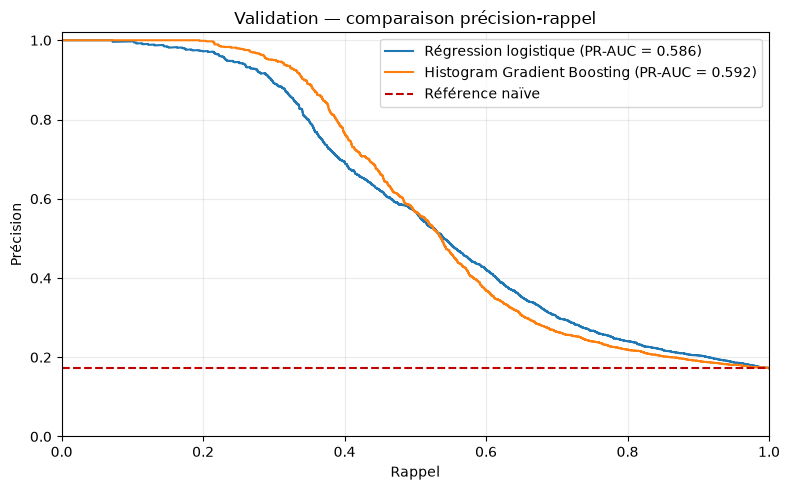

In [6]:
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score

scores = {'train': {}, 'validation': {}}
prediction_seconds = {'validation': {}}
for model_name, pipeline in models.items():
    scores['train'][model_name] = pipeline.predict_proba(X_train)[:, 1]
    started_at = perf_counter()
    scores['validation'][model_name] = pipeline.predict_proba(X_validation)[:, 1]
    prediction_seconds['validation'][model_name] = perf_counter() - started_at

validation_rows = []
for model_name in models:
    train_pr_auc = average_precision_score(y_train, scores['train'][model_name])
    validation_pr_auc = average_precision_score(y_validation, scores['validation'][model_name])
    validation_roc_auc = roc_auc_score(y_validation, scores['validation'][model_name])
    validation_rows.append([
        model_name,
        train_pr_auc,
        validation_pr_auc,
        validation_roc_auc,
        train_pr_auc - validation_pr_auc,
    ])

validation_comparison = pd.DataFrame(
    validation_rows,
    columns=['Modèle', 'PR-AUC train', 'PR-AUC validation', 'ROC-AUC validation', 'Écart train-validation'],
).set_index('Modèle')
print(validation_comparison.round(4).to_markdown())
print(f'\nRéférence naïve PR-AUC sur validation : {y_validation.mean():.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
for model_name in models:
    precision_curve, recall_curve, _ = precision_recall_curve(
        y_validation,
        scores['validation'][model_name],
    )
    ax.plot(
        recall_curve,
        precision_curve,
        label=f"{model_name} (PR-AUC = {validation_comparison.loc[model_name, 'PR-AUC validation']:.3f})",
    )
ax.axhline(y_validation.mean(), color='#C00000', linestyle='--', label='Référence naïve')
ax.set(title='Validation — comparaison précision-rappel', xlabel='Rappel', ylabel='Précision', xlim=(0, 1), ylim=(0, 1.02))
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


## Étape 3 — Choisir séparément les seuils F2 sur la validation

Un même seuil numérique n'est pas équitable : les deux modèles ne produisent pas leurs scores sur la même échelle. Nous choisissons donc, pour chacun, le seuil maximisant le **F2** sur la même validation. Le F2 combine précision et rappel en donnant davantage de poids au rappel, car manquer une panne est supposé plus coûteux qu'une inspection inutile.

La comparaison porte ensuite sur la précision, le rappel, F1, F2, les faux positifs et les faux négatifs. Aucun seuil n'est ajusté sur le test.


In [7]:
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)

BETA = 2

def choose_f2_threshold(y_true, model_scores):
    curve_precision, curve_recall, thresholds = precision_recall_curve(y_true, model_scores)
    usable_precision = curve_precision[:-1]
    usable_recall = curve_recall[:-1]
    f2_values = (1 + BETA**2) * usable_precision * usable_recall / (
        BETA**2 * usable_precision + usable_recall + np.finfo(float).eps
    )
    return float(thresholds[int(np.nanargmax(f2_values))])

def metrics_at_threshold(y_true, model_scores, threshold):
    predictions = (model_scores >= threshold).astype('int8')
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        'seuil': threshold,
        'précision': precision_score(y_true, predictions, zero_division=0),
        'rappel': recall_score(y_true, predictions, zero_division=0),
        'F1': f1_score(y_true, predictions, zero_division=0),
        'F2': fbeta_score(y_true, predictions, beta=BETA, zero_division=0),
        'VP': int(tp), 'FP': int(fp), 'FN': int(fn), 'VN': int(tn),
        'prédictions': predictions,
    }

selected_thresholds = {
    model_name: choose_f2_threshold(y_validation, scores['validation'][model_name])
    for model_name in models
}
validation_at_threshold = {
    model_name: metrics_at_threshold(
        y_validation,
        scores['validation'][model_name],
        selected_thresholds[model_name],
    )
    for model_name in models
}
threshold_rows = []
for model_name, result in validation_at_threshold.items():
    threshold_rows.append([
        model_name, result['seuil'], result['précision'], result['rappel'],
        result['F1'], result['F2'], result['FP'], result['FN'],
    ])
threshold_comparison = pd.DataFrame(
    threshold_rows,
    columns=['Modèle', 'Seuil F2', 'Précision', 'Rappel', 'F1', 'F2', 'FP', 'FN'],
).set_index('Modèle')
print(threshold_comparison.round(4).to_markdown())
print('\nLes deux seuils ont été choisis uniquement sur la validation.')


| Modèle                      |   Seuil F2 |   Précision |   Rappel |     F1 |     F2 |   FP |   FN |
|:----------------------------|-----------:|------------:|---------:|-------:|-------:|-----:|-----:|
| Régression logistique       |     0.3416 |      0.3385 |   0.6668 | 0.4491 | 0.5585 | 4523 | 1157 |
| Histogram Gradient Boosting |     0.2957 |      0.3901 |   0.5907 | 0.4699 | 0.5356 | 3206 | 1421 |

Les deux seuils ont été choisis uniquement sur la validation.


## Étape 4 — Évaluer une fois les modèles et seuils gelés sur le test

Les modèles et leurs seuils sont désormais figés. La cellule produit le tableau comparatif demandé : mêmes métriques, mêmes lignes de test et mesure indicative des temps d'entraînement et de prédiction.

Le temps observé dépend de la machine et ne constitue pas un benchmark universel. Il permet néanmoins d'évaluer le prix payé ici par `Histogram Gradient Boosting`. Le boosting corrige successivement ses erreurs et peut obtenir un meilleur classement sur données tabulaires. Il est toutefois plus sensible aux hyperparamètres et moins directement interprétable que la régression logistique.


| Modèle                      |   PR-AUC |   ROC-AUC |   Seuil gelé |   Précision |   Rappel |     F1 |     F2 |   FP |   FN |   Fit (s) |   Prédiction test (s) |
|:----------------------------|---------:|----------:|-------------:|------------:|---------:|-------:|-------:|-----:|-----:|----------:|----------------------:|
| Régression logistique       |   0.5769 |    0.7616 |       0.3416 |      0.3035 |   0.6981 | 0.423  | 0.554  | 5573 | 1050 |    0.9696 |                0.0129 |
| Histogram Gradient Boosting |   0.6157 |    0.7717 |       0.2957 |      0.3417 |   0.6622 | 0.4508 | 0.5576 | 4436 | 1175 |   10.9243 |                0.0386 |


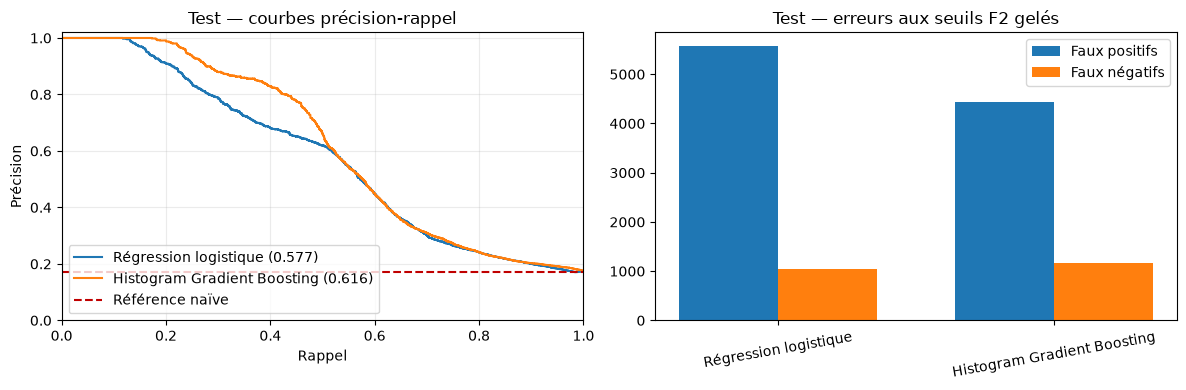

In [8]:
test_scores = {}
test_results = {}
prediction_seconds['test'] = {}
for model_name, pipeline in models.items():
    started_at = perf_counter()
    test_scores[model_name] = pipeline.predict_proba(X_test)[:, 1]
    prediction_seconds['test'][model_name] = perf_counter() - started_at
    threshold_metrics = metrics_at_threshold(
        y_test,
        test_scores[model_name],
        selected_thresholds[model_name],
    )
    test_results[model_name] = {
        'PR-AUC': average_precision_score(y_test, test_scores[model_name]),
        'ROC-AUC': roc_auc_score(y_test, test_scores[model_name]),
        **threshold_metrics,
    }

test_rows = []
for model_name, result in test_results.items():
    test_rows.append([
        model_name, result['PR-AUC'], result['ROC-AUC'], result['seuil'],
        result['précision'], result['rappel'], result['F1'], result['F2'],
        result['FP'], result['FN'], fit_seconds[model_name],
        prediction_seconds['test'][model_name],
    ])
test_comparison = pd.DataFrame(
    test_rows,
    columns=[
        'Modèle', 'PR-AUC', 'ROC-AUC', 'Seuil gelé', 'Précision', 'Rappel',
        'F1', 'F2', 'FP', 'FN', 'Fit (s)', 'Prédiction test (s)',
    ],
).set_index('Modèle')
print(test_comparison.round(4).to_markdown())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for model_name in models:
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_scores[model_name])
    axes[0].plot(recall_curve, precision_curve, label=f"{model_name} ({test_results[model_name]['PR-AUC']:.3f})")
axes[0].axhline(y_test.mean(), color='#C00000', linestyle='--', label='Référence naïve')
axes[0].set(title='Test — courbes précision-rappel', xlabel='Rappel', ylabel='Précision', xlim=(0, 1), ylim=(0, 1.02))
axes[0].grid(alpha=0.25)
axes[0].legend()

x_positions = np.arange(len(models))
axes[1].bar(x_positions - 0.18, [test_results[name]['FP'] for name in models], width=0.36, label='Faux positifs')
axes[1].bar(x_positions + 0.18, [test_results[name]['FN'] for name in models], width=0.36, label='Faux négatifs')
axes[1].set_xticks(x_positions, list(models), rotation=10)
axes[1].set_title('Test — erreurs aux seuils F2 gelés')
axes[1].legend()
plt.tight_layout()
plt.show()


## Étape 5 — L'écart de PR-AUC est-il robuste ?

Un écart brut ne suffit pas à démontrer qu'un modèle est réellement meilleur. Le **bootstrap** rééchantillonne les données pour estimer la variabilité du résultat. Comme les observations sont temporelles et que des fenêtres voisines se recouvrent, nous rééchantillonnons des blocs consécutifs de 24 observations au sein des machines plutôt que des lignes isolées.

Si l'intervalle à 95 % de la différence de PR-AUC contient zéro, nous ne pouvons pas conclure à un écart robuste avec ce protocole. Même s'il l'exclut, ce résultat reste une estimation pédagogique : seules 15 machines sont présentes et le test a déjà été consulté lors du TP initial.


In [9]:
# Bootstrap apparié par blocs de 24 observations consécutives au sein de chaque machine.
test_metadata = gold.loc[
    gold[SPLIT_COLUMN].eq('test'),
    ['machine_id_std', PREDICTION_TIME_COLUMN],
].reset_index(drop=True)
test_blocks = []
for _, machine_rows in test_metadata.groupby('machine_id_std', sort=False):
    positions = machine_rows.index.to_numpy()
    test_blocks.extend(positions[start:start + 24] for start in range(0, len(positions), 24))

rng = np.random.default_rng(42)
bootstrap_differences = []
baseline_name = 'Régression logistique'
candidate_name = 'Histogram Gradient Boosting'
y_test_array = y_test.to_numpy()
for _ in range(300):
    sampled_blocks = rng.integers(0, len(test_blocks), size=len(test_blocks))
    sampled_positions = np.concatenate([test_blocks[index] for index in sampled_blocks])
    sampled_target = y_test_array[sampled_positions]
    if sampled_target.min() == sampled_target.max():
        continue
    baseline_ap = average_precision_score(sampled_target, test_scores[baseline_name][sampled_positions])
    candidate_ap = average_precision_score(sampled_target, test_scores[candidate_name][sampled_positions])
    bootstrap_differences.append(candidate_ap - baseline_ap)

observed_difference = test_results[candidate_name]['PR-AUC'] - test_results[baseline_name]['PR-AUC']
ci_low, ci_high = np.percentile(bootstrap_differences, [2.5, 97.5])
print(f'Écart observé de PR-AUC ({candidate_name} - baseline) : {observed_difference:+.4f}')
print(f'Intervalle bootstrap par blocs à 95 % : [{ci_low:+.4f} ; {ci_high:+.4f}]')
if ci_low > 0 or ci_high < 0:
    print("L'intervalle exclut 0 : l'écart est robuste dans ce bootstrap par blocs.")
else:
    print("L'intervalle contient 0 : ce protocole ne met pas en évidence un écart robuste.")
print("Cette estimation tient compte de la dépendance locale sur 24 heures, mais pas de toutes les dépendances entre fenêtres ni du fait que ce test a déjà été consulté lors du TP initial.")


Écart observé de PR-AUC (Histogram Gradient Boosting - baseline) : +0.0388
Intervalle bootstrap par blocs à 95 % : [+0.0133 ; +0.0639]
L'intervalle exclut 0 : l'écart est robuste dans ce bootstrap par blocs.
Cette estimation tient compte de la dépendance locale sur 24 heures, mais pas de toutes les dépendances entre fenêtres ni du fait que ce test a déjà été consulté lors du TP initial.


## Étape 6 — Comparer l'interprétabilité

Les coefficients de la régression logistique donnent directement le sens de l'association après standardisation. Pour `Histogram Gradient Boosting`, nous utilisons une **importance par permutation** : une feature est mélangée et l'on mesure la baisse de PR-AUC. Une forte baisse indique que le modèle utilisait cette information.

Cette méthode est plus coûteuse et ne fournit ni règle causale ni sens simple de l'effet. Des features corrélées peuvent également se partager l'importance.


In [10]:
from sklearn.inspection import permutation_importance

# Échantillon temporel régulier pour limiter le coût sans tirer des lignes au hasard.
importance_positions = np.linspace(0, len(X_validation) - 1, num=min(5000, len(X_validation)), dtype=int)
importance_result = permutation_importance(
    candidate_pipeline,
    X_validation.iloc[importance_positions],
    y_validation.iloc[importance_positions],
    scoring='average_precision',
    n_repeats=3,
    random_state=42,
    n_jobs=-1,
)
candidate_importances = pd.DataFrame({
    'feature': feature_columns,
    'baisse_PR_AUC_moyenne': importance_result.importances_mean,
    'écart_type': importance_result.importances_std,
}).sort_values('baisse_PR_AUC_moyenne', ascending=False).head(12)
print(candidate_importances.round(4).to_markdown(index=False))
print("\nUne importance par permutation mesure la baisse de PR-AUC lorsque la feature est mélangée. Elle décrit l'utilité prédictive du modèle, pas une causalité.")


| feature                        |   baisse_PR_AUC_moyenne |   écart_type |
|:-------------------------------|------------------------:|-------------:|
| incident_count_prev_24h        |                  0.2587 |       0.0023 |
| incident_max_severity_prev_24h |                  0.0318 |       0.0009 |
| incident_count_1h              |                  0.0259 |       0.0026 |
| incident_count_prev_7d         |                  0.0191 |       0.0014 |
| pressure_std_24h               |                  0.0097 |       0.0012 |
| temp_mean_24h                  |                  0.0094 |       0.0016 |
| voltage_max_24h                |                  0.0085 |       0.0015 |
| hours_since_last_incident      |                  0.0076 |       0.0011 |
| pressure_max_24h               |                  0.007  |       0.0005 |
| voltage_mean_1h                |                  0.0062 |       0.0002 |
| voltage_mean_24h               |                  0.0056 |       0.0014 |
| temp_max_2

## Étape 7 — Recommandation argumentée

La règle de décision annoncée avant la conclusion est la suivante : recommander le modèle complexe seulement si, **sur la validation**, son gain de PR-AUC atteint au moins `0,01` et si son F2 ne baisse pas de plus de `0,01`. Le test sert ensuite à vérifier la généralisation de cette décision, pas à choisir le gagnant. Sinon, conserver la régression logistique, plus simple à expliquer et à maintenir.

Cette règle n'est pas universelle : elle rend explicite le compromis retenu pour ce TP. En production, elle devrait être remplacée par les coûts réels d'une panne manquée, d'une fausse alerte et du traitement opérationnel.


In [11]:
baseline_result = test_results['Régression logistique']
candidate_result = test_results['Histogram Gradient Boosting']
validation_pr_auc_gain = (
    validation_comparison.loc['Histogram Gradient Boosting', 'PR-AUC validation']
    - validation_comparison.loc['Régression logistique', 'PR-AUC validation']
)
validation_f2_gain = (
    validation_at_threshold['Histogram Gradient Boosting']['F2']
    - validation_at_threshold['Régression logistique']['F2']
)
test_pr_auc_gain = candidate_result['PR-AUC'] - baseline_result['PR-AUC']
test_f2_gain = candidate_result['F2'] - baseline_result['F2']
fit_ratio = fit_seconds['Histogram Gradient Boosting'] / max(fit_seconds['Régression logistique'], np.finfo(float).eps)

if validation_pr_auc_gain >= 0.01 and validation_f2_gain >= -0.01:
    recommendation = 'Histogram Gradient Boosting'
    rationale = "sur la validation, le gain de PR-AUC atteint 0,01 et le F2 ne se dégrade pas de plus de 0,01"
else:
    recommendation = 'Régression logistique'
    rationale = "sur la validation, le gain du modèle complexe ne satisfait pas simultanément les critères de classement et d'utilité opérationnelle"

print(f'Modèle recommandé dans ce TP : {recommendation}')
print(f'Raison : {rationale}.')
print(f'Écarts sur validation — PR-AUC : {validation_pr_auc_gain:+.4f} ; F2 : {validation_f2_gain:+.4f}.')
print(f'Confirmation sur test — PR-AUC : {test_pr_auc_gain:+.4f} ; F2 : {test_f2_gain:+.4f}.')
print(f'Rapport de temps de fit candidat / baseline : {fit_ratio:.1f} fois.')
print('La régression logistique reste la plus directement interprétable par ses coefficients ; le candidat représente les non-linéarités, mais demande une interprétation indirecte par permutation.')

assert all(result['PR-AUC'] > y_test.mean() for result in test_results.values())
assert all(0 < threshold < 1 for threshold in selected_thresholds.values())
assert len(bootstrap_differences) >= 250
print('\nTP_COMPARATIF_VALIDE : données, seuils, métriques, coût et conclusion comparés sans fuite future identifiée.')


Modèle recommandé dans ce TP : Régression logistique
Raison : sur la validation, le gain du modèle complexe ne satisfait pas simultanément les critères de classement et d'utilité opérationnelle.
Écarts sur validation — PR-AUC : +0.0061 ; F2 : -0.0228.
Confirmation sur test — PR-AUC : +0.0388 ; F2 : +0.0036.
Rapport de temps de fit candidat / baseline : 11.3 fois.
La régression logistique reste la plus directement interprétable par ses coefficients ; le candidat représente les non-linéarités, mais demande une interprétation indirecte par permutation.

TP_COMPARATIF_VALIDE : données, seuils, métriques, coût et conclusion comparés sans fuite future identifiée.


## Bilan à savoir expliquer lors de la soutenance

- Les modèles ont reçu les mêmes observations, les mêmes 88 features et le même découpage temporel.
- Les hyperparamètres de `Histogram Gradient Boosting` ont été choisis manuellement et documentés, sans recherche sur le test.
- La PR-AUC compare le classement sur une classe minoritaire ; le F2 traduit la préférence pour le rappel après choix du seuil sur validation.
- Le bootstrap par blocs nuance l'écart observé, sans transformer cette expérience en preuve définitive de production.
- Le choix final pèse performance, erreurs opérationnelles, temps de calcul, complexité et interprétabilité.

**Erreurs fréquentes :** comparer des modèles sur des partitions différentes, garder le même seuil par convention, choisir les hyperparamètres sur le test, conclure à partir de l'accuracy seule ou interpréter une importance comme une cause physique.
